In [1]:
import pandas as pd
import numpy as np
import os
import random
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import shap
from scripts.preprocessing import load_data, test_stationarity
from scripts.econometrics_models import grid_search_sarimax
from scripts.ml_models import prepare_ml_data, train_xgb_model
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scripts.evaluation import calculate_metrics
from scripts.visualization import plot_predictions, plot_multiple_preds

import warnings
warnings.filterwarnings('ignore')

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

c:\Users\lapto\Magisterka_Pawel\master_degree\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_data('data/dane_2010plus.xlsx')
df.describe()

,stopa_bezrobocia,Produkt krajowy brutto [GUS],płaca_minimalna [brutto],inflacja [%],przyrost naturalny,Przeciętne_msc_wynag_brutto_sektor_przedsię [zł],Oferty pracy - stan na koniec miesiąca
count,180.000000,1.800000e+02,180.000000,180.000000,180.000000,180.000000,180.000000
mean,8.626667,5.542330e+05,2243.933333,3.591667,-4499.444444,4997.643333,68422.222222
std,3.224810,1.733330e+05,826.486064,4.344751,7961.081993,1428.804569,23489.770876
min,4.900000,3.300532e+05,1317.000000,-1.600000,-39200.000000,3231.130000,22000.000000
25%,5.675000,4.156350e+05,1600.000000,1.075000,-8600.000000,3854.397500,48325.000000
50%,7.050000,5.044142e+05,2000.000000,2.550000,-2650.000000,4511.680000,65250.000000
75%,11.900000,6.509255e+05,2800.000000,4.300000,725.000000,5803.245000,85425.000000
max,14.400000,1.013360e+06,4300.000000,18.400000,7900.000000,8821.250000,120300.000000


In [3]:
stationarity_result = test_stationarity(df['stopa_bezrobocia'])
print("Wynik testu stacjonarności:")
stationarity_result

Wynik testu stacjonarności:


{'ADF Statistic': np.float64(-1.4234145794904554),
 'p-value': np.float64(0.571000834025678),
 'Critical Values': {'1%': np.float64(-3.470616369591229),
  '5%': np.float64(-2.8792214018977655),
  '10%': np.float64(-2.57619681359045)},
 'Stationary': np.False_}

In [4]:
df['stopa_bezrobocia_diff'] = df['stopa_bezrobocia'].diff()

stationarity_result = test_stationarity(df['stopa_bezrobocia_diff'].dropna())
print("Wynik testu stacjonarności (dla przyrostu):")
stationarity_result

Wynik testu stacjonarności (dla przyrostu):


{'ADF Statistic': np.float64(-2.219845299103094),
 'p-value': np.float64(0.19912175853140157),
 'Critical Values': {'1%': np.float64(-3.470616369591229),
  '5%': np.float64(-2.8792214018977655),
  '10%': np.float64(-2.57619681359045)},
 'Stationary': np.False_}

In [5]:
df['stopa_bezrobocia_diff2'] = df['stopa_bezrobocia_diff'].diff()

stationarity_result = test_stationarity(df['stopa_bezrobocia_diff2'].dropna())
print("ADF dla 2. różnicowania:")
stationarity_result

ADF dla 2. różnicowania:


{'ADF Statistic': np.float64(-4.9160835077721154),
 'p-value': np.float64(3.244569918518262e-05),
 'Critical Values': {'1%': np.float64(-3.470616369591229),
  '5%': np.float64(-2.8792214018977655),
  '10%': np.float64(-2.57619681359045)},
 'Stationary': np.True_}

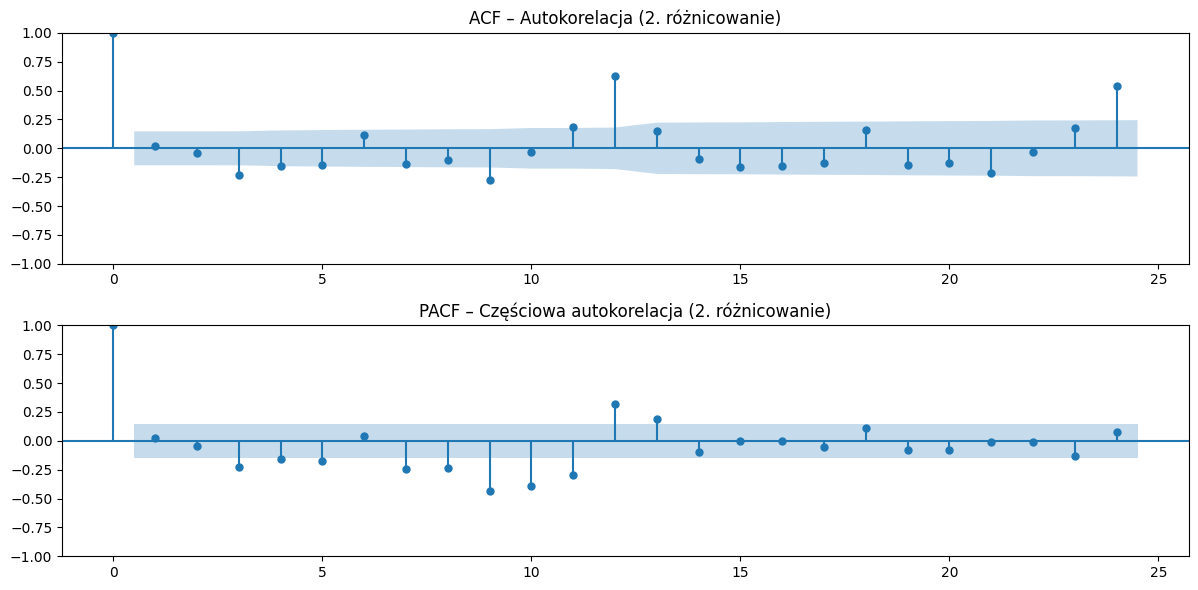

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(df['stopa_bezrobocia_diff2'].dropna(), lags=24, ax=ax[0])
ax[0].set_title('ACF – Autokorelacja (2. różnicowanie)')

plot_pacf(df['stopa_bezrobocia_diff2'].dropna(), lags=24, ax=ax[1])
ax[1].set_title('PACF – Częściowa autokorelacja (2. różnicowanie)')

plt.tight_layout()
plt.show()

SARIMAX (diff 2)

In [7]:
# df['stopa_bezrobocia_diff']  = df['stopa_bezrobocia'].diff()
# df['stopa_bezrobocia_diff2'] = df['stopa_bezrobocia_diff'].diff()
# df2   = df.dropna(subset=['stopa_bezrobocia_diff2'])
# train_end     = -24
# series_train  = df2['stopa_bezrobocia_diff2'].iloc[:train_end]
# series_test   = df2['stopa_bezrobocia_diff2'].iloc[ train_end:]

train_end     = -24
series_train  = df['stopa_bezrobocia'].iloc[:train_end]
series_test   = df['stopa_bezrobocia'].iloc[ train_end:]

In [8]:
result = grid_search_sarimax(
    series=series_train,
    p_range=range(0, 3),
    d_range=[1,2],
    q_range=range(0, 3),
    P_range=range(0, 2),
    D_range=[0],
    Q_range=range(0, 2),
    seasonal_period=12,
    verbose=False
)

In [9]:
best_sarimax_diff2 = result['best_model']
print("Najlepsze parasemetry:", result['order'], result['seasonal_order'])

Najlepsze parasemetry: (1, 1, 1) (1, 0, 1, 12)


In [10]:
best_sarimax_diff2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                   stopa_bezrobocia   No. Observations:                  156
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 104.712
Date:                            Tue, 29 Jul 2025   AIC                           -199.425
Time:                                    19:26:09   BIC                           -184.681
Sample:                                01-01-2010   HQIC                          -193.433
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9216      0.050     18.272      0.000       0.823       1.021
ma.L1         -0.6594      0.083     -7.946      0.000      -0.822      -0.497
ar.S.L12       0.8804      0.014     61.850      0.000       0.852       0.908
ma.S.L12      -1.3988      0.218     -6.415      0.000      -1.826      -0.971
sigma2         0.0064      0.002      3.325      0.001       0.003       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               697.44
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               2.26   Skew:                             2.09
Prob(H) (two-sided):                  0.01   Kurtosis:                        13.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Model SARIMA → y:
 {'MSE': 0.097757515850879, 'RMSE': np.float64(0.312661983379622), 'MAE': 0.28433492871250887}


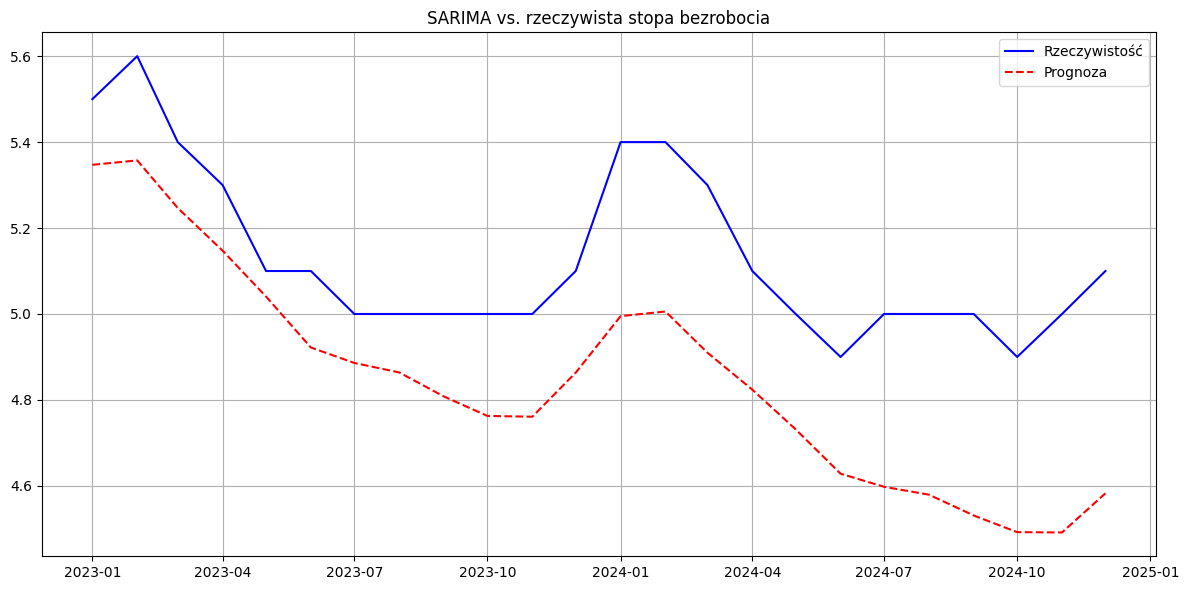

In [11]:
forecast_diff2 = best_sarimax_diff2.get_forecast(
    steps=len(series_test)
).predicted_mean
forecast_diff2.index = series_test.index
y_test = series_test

metrics_sarima_diff2 = calculate_metrics(y_test, forecast_diff2)
print("Model SARIMA → y:\n", metrics_sarima_diff2)

plot_predictions(
    y_test,
    forecast_diff2,
    title="SARIMA vs. rzeczywista stopa bezrobocia"
)

SARIMAX (diff 2) z dodatkowymi zmiennymi

In [12]:
train = df.iloc[:-24]
test  = df.iloc[-24:]

series_train = train['stopa_bezrobocia']
series_test  = test ['stopa_bezrobocia']

exog_vars = [
    'Produkt krajowy brutto [GUS]',
    'płaca_minimalna [brutto]',
    'inflacja [%]',
    'przyrost naturalny',
    'Przeciętne_msc_wynag_brutto_sektor_przedsię [zł]',
    'Oferty pracy - stan na koniec miesiąca'
]
exog_train = train[exog_vars]
exog_test  = test [exog_vars]

In [13]:
result = grid_search_sarimax(
    series         = series_train,
    exog           = exog_train,
    p_range        = range(0, 3),
    d_range        = [2],       # automatyczne różnicowanie
    q_range        = range(0, 3),
    P_range        = range(0, 2),
    D_range        = [1],          # sezonowe różnicowanie
    Q_range        = range(0, 2),
    seasonal_period=12,
    verbose        = True
)

best_sarimax = result['best_model']
print("Najlepsze parametry:", result['order'], result['seasonal_order'])

Tested SARIMAX(0, 2, 0)x(0, 1, 0, 12) - AIC: 444.76, BIC: 465.40 (1/36)
Tested SARIMAX(0, 2, 0)x(0, 1, 1, 12) - AIC: -127.12, BIC: -104.24 (2/36)
Tested SARIMAX(0, 2, 0)x(1, 1, 0, 12) - AIC: -131.15, BIC: -108.21 (3/36)
Tested SARIMAX(0, 2, 0)x(1, 1, 1, 12) - AIC: -127.22, BIC: -101.48 (4/36)
Tested SARIMAX(0, 2, 1)x(0, 1, 0, 12) - AIC: -138.97, BIC: -115.43 (5/36)
Tested SARIMAX(0, 2, 1)x(0, 1, 1, 12) - AIC: -147.03, BIC: -121.36 (6/36)
Tested SARIMAX(0, 2, 1)x(1, 1, 0, 12) - AIC: -149.64, BIC: -123.83 (7/36)
Tested SARIMAX(0, 2, 1)x(1, 1, 1, 12) - AIC: -146.45, BIC: -117.93 (8/36)
Tested SARIMAX(0, 2, 2)x(0, 1, 0, 12) - AIC: -139.30, BIC: -112.89 (9/36)
Tested SARIMAX(0, 2, 2)x(0, 1, 1, 12) - AIC: -145.70, BIC: -117.26 (10/36)
Tested SARIMAX(0, 2, 2)x(1, 1, 0, 12) - AIC: -150.54, BIC: -121.86 (11/36)
Tested SARIMAX(0, 2, 2)x(1, 1, 1, 12) - AIC: -145.52, BIC: -114.24 (12/36)
Tested SARIMAX(1, 2, 0)x(0, 1, 0, 12) - AIC: -132.26, BIC: -108.67 (13/36)
Tested SARIMAX(1, 2, 0)x(0, 1, 1, 12

In [14]:
best_sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                    stopa_bezrobocia   No. Observations:                  156
Model:             SARIMAX(0, 2, 2)x(1, 1, [], 12)   Log Likelihood                  85.269
Date:                             Tue, 29 Jul 2025   AIC                           -150.539
Time:                                     19:26:33   BIC                           -121.864
Sample:                                 01-01-2010   HQIC                          -138.887
                                      - 12-01-2022                                         
Covariance Type:                               opg                                         
====================================================================================================================
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Produkt krajowy brutto [GUS]                     -2.996e-06   1.12e-06     -2.684      0.007   -5.18e-06   -8.09e-07
płaca_minimalna [brutto]                             0.0011      0.000      3.241      0.001       0.000       0.002
inflacja [%]                                        -0.0025      0.023     -0.105      0.916      -0.048       0.043
przyrost naturalny                                6.503e-06   1.49e-06      4.351      0.000    3.57e-06    9.43e-06
Przeciętne_msc_wynag_brutto_sektor_przedsię [zł]    -0.0002      0.000     -1.314      0.189      -0.001       0.000
Oferty pracy - stan na koniec miesiąca           -9.348e-07   1.59e-06     -0.587      0.557   -4.06e-06    2.19e-06
ma.L1                                               -0.4894      0.099     -4.922      0.000      -0.684      -0.294
ma.L2                                               -0.0462      0.120     -0.385      0.700      -0.282       0.189
ar.S.L12                                            -0.3132      0.104     -3.005      0.003      -0.517      -0.109
sigma2                                               0.0187      0.003      6.604      0.000       0.013       0.024
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                12.00
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               3.04   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX (oryginał) na zbiorze testowym:
{'MSE': 0.7021651395494786, 'RMSE': np.float64(0.837952945904171), 'MAE': 0.6709877633093271}


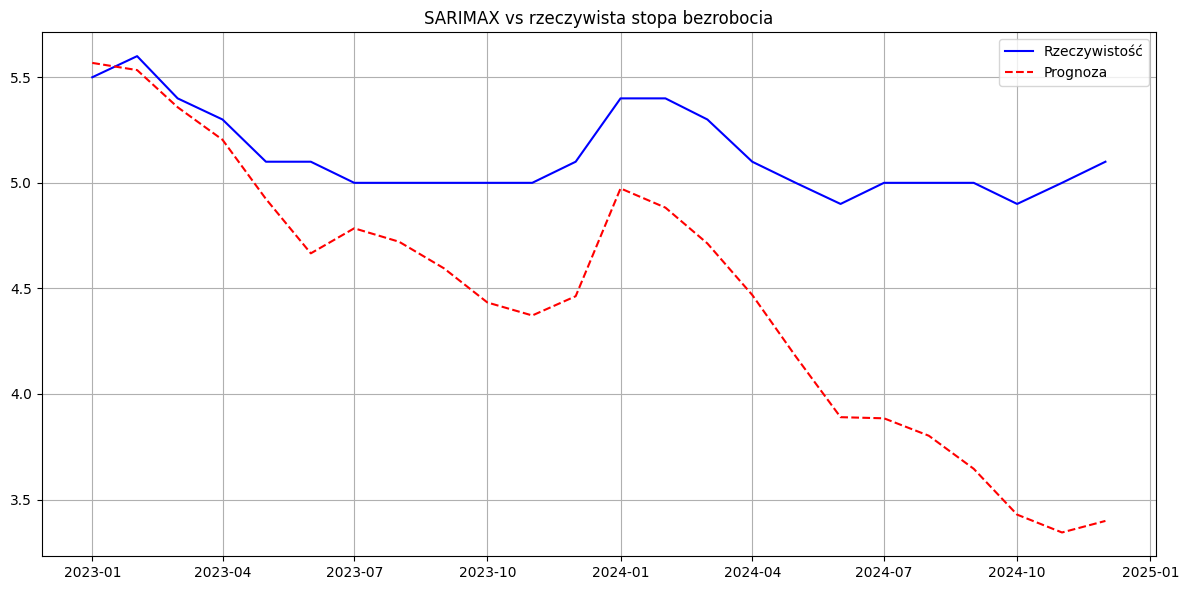

In [15]:
sarima_diff2_exog_forecast = best_sarimax.get_forecast(
    steps=len(series_test),
    exog=exog_test
).predicted_mean
sarima_diff2_exog_forecast.index = series_test.index

metrics_sarima_diff2_exog = calculate_metrics(series_test, sarima_diff2_exog_forecast)
print("SARIMAX (oryginał) na zbiorze testowym:")
print(metrics_sarima_diff2_exog)

plot_predictions(
    series_test,
    sarima_diff2_exog_forecast,
    title="SARIMAX vs rzeczywista stopa bezrobocia"
)

In [16]:
# Wyciągnięcie współczynników i p-value
params_table = pd.DataFrame({
    'coef': best_sarimax.params,
    'pvalue': best_sarimax.pvalues
})
print("Tabela parametrów SARIMAX:")
display(params_table)

# Podział na AR/MA, Seasonal, Exogenous
ar_ma = params_table.loc[[c for c in params_table.index if c.startswith('ar.') or c.startswith('ma.')]]
seasonal = params_table.loc[[c for c in params_table.index if '.S.' in c]]
exog_coefs = params_table.loc[exog_vars]

Tabela parametrów SARIMAX:


,coef,pvalue
Produkt krajowy brutto [GUS],-2.996150e-06,7.264843e-03
płaca_minimalna [brutto],1.088096e-03,1.189320e-03
inflacja [%],-2.467422e-03,9.161936e-01
przyrost naturalny,6.502565e-06,1.352238e-05
Przeciętne_msc_wynag_brutto_sektor_przedsię [zł],-2.478182e-04,1.888443e-01
Oferty pracy - stan na koniec miesiąca,-9.347609e-07,5.572271e-01
ma.L1,-4.893741e-01,8.576077e-07
ma.L2,-4.622384e-02,7.004565e-01
ar.S.L12,-3.131874e-01,2.659636e-03
sigma2,1.866809e-02,3.990454e-11


In [17]:
# 1. Wyodrębnij istotne exog_vars
significant_exog = exog_coefs[exog_coefs['pvalue'] < 0.05].index.tolist()
print("Znaczące zmienne egzogeniczne (p<0.05):", significant_exog)

# 2. Przygotuj nowe exog dla train/test
exog_train_sig = exog_train[significant_exog]
exog_test_sig  = exog_test[significant_exog]

# 3. Grid search SARIMAX na oryginale z wybranymi exogenous
result_sig = grid_search_sarimax(
    series=series_train,
    exog=exog_train_sig,
    p_range=range(0, 3),
    d_range=[0, 1,2],
    q_range=range(0, 3),
    P_range=range(0, 2),
    D_range=[0, 1,2],
    Q_range=range(0, 2),
    seasonal_period=12,
    verbose=False
)

best_sarimax_sig = result_sig['best_model']
print("Optymalne parametry (z istotnymi exog):", result_sig['order'], result_sig['seasonal_order'])

Znaczące zmienne egzogeniczne (p<0.05): ['Produkt krajowy brutto [GUS]', 'płaca_minimalna [brutto]', 'przyrost naturalny']
Optymalne parametry (z istotnymi exog): (2, 1, 0) (0, 1, 1, 12)


In [18]:
best_sarimax_sig.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                     stopa_bezrobocia   No. Observations:                  156
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                  90.653
Date:                              Tue, 29 Jul 2025   AIC                           -167.307
Time:                                      19:29:22   BIC                           -147.234
Sample:                                  01-01-2010   HQIC                          -159.150
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Produkt krajowy brutto [GUS] -5.403e-06   8.81e-07     -6.130      0.000   -7.13e-06   -3.68e-06
płaca_minimalna [brutto]      -8.83e-05      0.001     -0.113      0.910      -0.002       0.001
przyrost naturalny            3.577e-06   1.61e-06      2.217      0.027    4.15e-07    6.74e-06
ar.L1                            0.3230      0.101      3.198      0.001       0.125       0.521
ar.L2                            0.2634      0.138      1.906      0.057      -0.007       0.534
ma.S.L12                        -0.3550      0.087     -4.084      0.000      -0.525      -0.185
sigma2                           0.0178      0.003      6.341      0.000       0.012       0.023
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                34.67
Prob(Q):                              0.62   Prob(JB):                         0.00
Heteroskedasticity (H):               2.56   Skew:                             0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX (tylko istotne exog) na testowym:
{'MSE': 0.18031441653783142, 'RMSE': np.float64(0.42463445048397974), 'MAE': 0.37041310817434087}


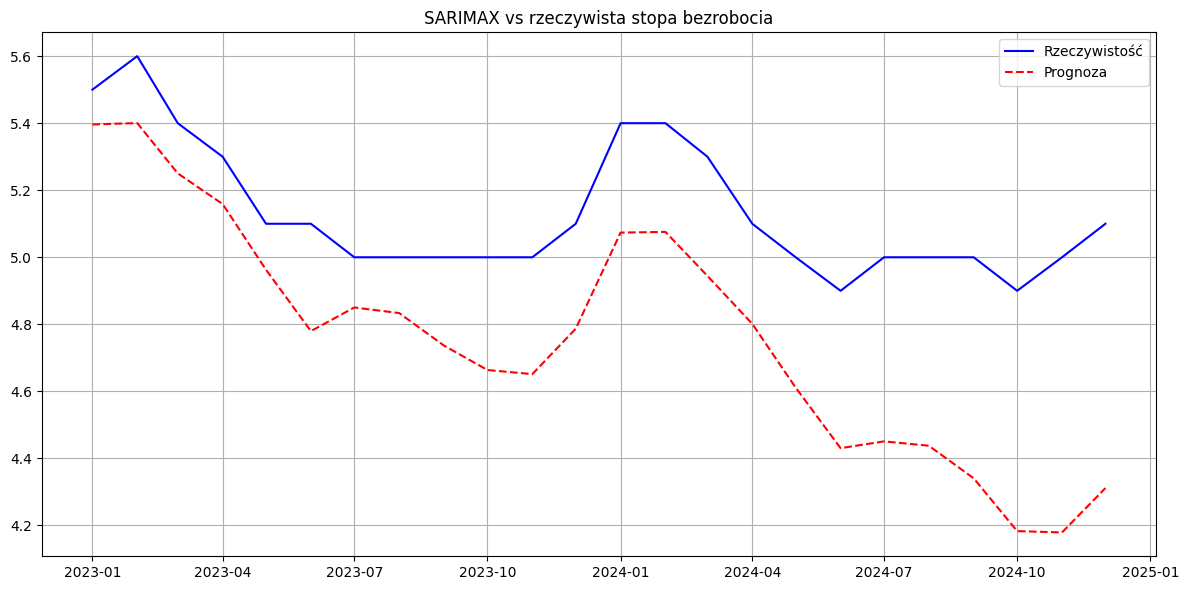

In [19]:
# 4. Prognoza i ewaluacja
sarima_diff2_exog_forecast = best_sarimax_sig.get_forecast(
    steps=len(series_test),
    exog=exog_test_sig
).predicted_mean
sarima_diff2_exog_forecast.index = series_test.index

metrics_sarima_diff2_exog = calculate_metrics(series_test, sarima_diff2_exog_forecast)
print("SARIMAX (tylko istotne exog) na testowym:")
print(metrics_sarima_diff2_exog)

plot_predictions(
    series_test,
    sarima_diff2_exog_forecast,
    title="SARIMAX vs rzeczywista stopa bezrobocia"
)

In [20]:
best_sarimax_sig.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                     stopa_bezrobocia   No. Observations:                  156
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                  90.653
Date:                              Tue, 29 Jul 2025   AIC                           -167.307
Time:                                      19:29:23   BIC                           -147.234
Sample:                                  01-01-2010   HQIC                          -159.150
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Produkt krajowy brutto [GUS] -5.403e-06   8.81e-07     -6.130      0.000   -7.13e-06   -3.68e-06
płaca_minimalna [brutto]      -8.83e-05      0.001     -0.113      0.910      -0.002       0.001
przyrost naturalny            3.577e-06   1.61e-06      2.217      0.027    4.15e-07    6.74e-06
ar.L1                            0.3230      0.101      3.198      0.001       0.125       0.521
ar.L2                            0.2634      0.138      1.906      0.057      -0.007       0.534
ma.S.L12                        -0.3550      0.087     -4.084      0.000      -0.525      -0.185
sigma2                           0.0178      0.003      6.341      0.000       0.012       0.023
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                34.67
Prob(Q):                              0.62   Prob(JB):                         0.00
Heteroskedasticity (H):               2.56   Skew:                             0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [21]:
exog_train_sig.columns

Index(['Produkt krajowy brutto [GUS]', 'płaca_minimalna [brutto]',
       'przyrost naturalny'],
      dtype='object')

In [22]:
# Wyciągnięcie współczynników i p-value
params_table = pd.DataFrame({
    'coef': best_sarimax_sig.params,
    'pvalue': best_sarimax_sig.pvalues
})
print("Tabela parametrów SARIMAX:")
display(params_table)

# Podział na AR/MA, Seasonal, Exogenous
exog_coefs_2 = params_table.loc[exog_train_sig.columns]
# 1. Wyodrębnij istotne exog_vars
significant_exog_2 = exog_coefs_2[exog_coefs_2['pvalue'] < 0.05].index.tolist()
print("Znaczące zmienne egzogeniczne (p<0.05):", significant_exog_2)

Tabela parametrów SARIMAX:


,coef,pvalue
Produkt krajowy brutto [GUS],-0.000005,8.789521e-10
płaca_minimalna [brutto],-0.000088,9.103312e-01
przyrost naturalny,0.000004,2.659415e-02
ar.L1,0.322978,1.382202e-03
ar.L2,0.263435,5.665102e-02
ma.S.L12,-0.354957,4.427986e-05
sigma2,0.017779,2.275902e-10


Znaczące zmienne egzogeniczne (p<0.05): ['Produkt krajowy brutto [GUS]', 'przyrost naturalny']


Optymalne parametry (z istotnymi exog): (2, 1, 0) (0, 1, 1, 12)
SARIMAX (tylko istotne exog) na testowym:
{'MSE': 0.14076037725824694, 'RMSE': np.float64(0.37518045959011104), 'MAE': 0.32292674797448906}


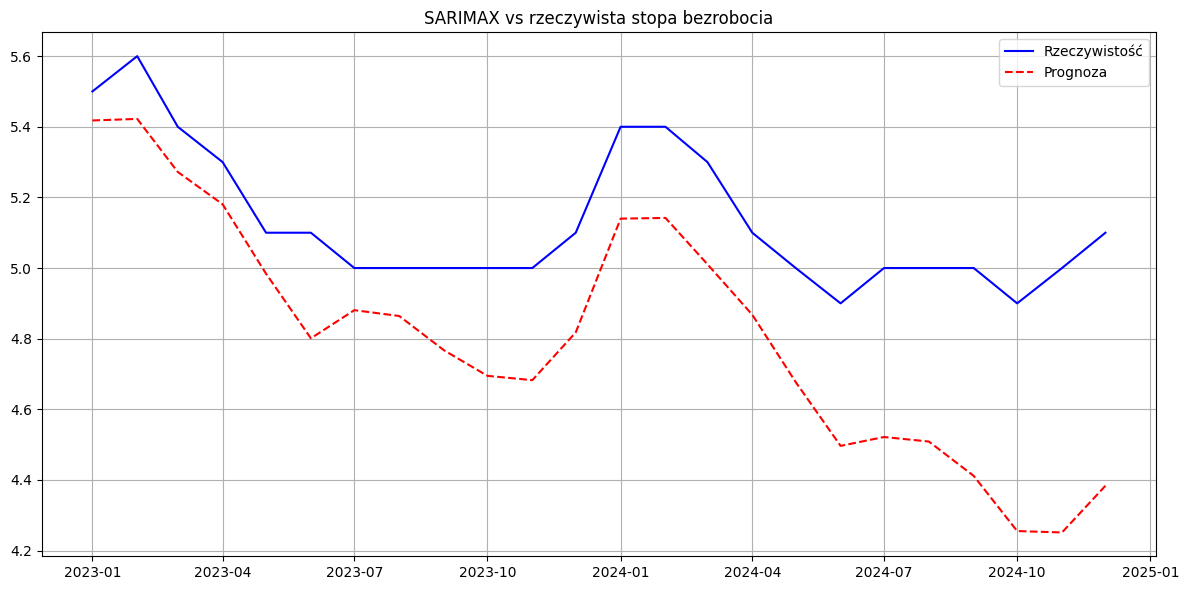

In [23]:
# 2. Przygotuj nowe exog dla train/test
exog_train_sig_2 = exog_train[significant_exog_2]
exog_test_sig_2 = exog_test[significant_exog_2]

# 3. Grid search SARIMAX na oryginale z wybranymi exogenous
result_sig_2 = grid_search_sarimax(
    series=series_train,
    exog=exog_train_sig_2,
    p_range=range(0, 3),
    d_range=[0, 1,2],
    q_range=range(0, 3),
    P_range=range(0, 2),
    D_range=[0, 1,2],
    Q_range=range(0, 2),
    seasonal_period=12,
    verbose=False
)

best_sarimax_sig_2 = result_sig_2['best_model']
print("Optymalne parametry (z istotnymi exog):", result_sig_2['order'], result_sig_2['seasonal_order'])

# 4. Prognoza i ewaluacja
sarima_diff2_exog_forecast_2 = best_sarimax_sig_2.get_forecast(
    steps=len(series_test),
    exog=exog_test_sig_2
).predicted_mean
sarima_diff2_exog_forecast_2.index = series_test.index

metrics_sarima_diff2_exog_2 = calculate_metrics(series_test, sarima_diff2_exog_forecast_2)
print("SARIMAX (tylko istotne exog) na testowym:")
print(metrics_sarima_diff2_exog_2)

plot_predictions(
    series_test,
    sarima_diff2_exog_forecast_2,
    title="SARIMAX vs rzeczywista stopa bezrobocia"
)

In [24]:
best_sarimax_sig_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                     stopa_bezrobocia   No. Observations:                  156
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                  90.654
Date:                              Tue, 29 Jul 2025   AIC                           -169.308
Time:                                      19:32:03   BIC                           -152.102
Sample:                                  01-01-2010   HQIC                          -162.317
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Produkt krajowy brutto [GUS] -5.362e-06   8.69e-07     -6.174      0.000   -7.06e-06   -3.66e-06
przyrost naturalny            3.605e-06   1.59e-06      2.273      0.023    4.97e-07    6.71e-06
ar.L1                            0.3281      0.091      3.607      0.000       0.150       0.506
ar.L2                            0.2583      0.134      1.925      0.054      -0.005       0.521
ma.S.L12                        -0.3534      0.087     -4.071      0.000      -0.524      -0.183
sigma2                           0.0178      0.003      6.415      0.000       0.012       0.023
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):                34.60
Prob(Q):                              0.63   Prob(JB):                         0.00
Heteroskedasticity (H):               2.58   Skew:                             0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX na tym samym modelu co SARIMA

Optymalne parametry (z istotnymi exog): (1, 1, 1) (1, 0, 1, 12)
SARIMAX (tylko istotne exog) na testowym:
{'MSE': 0.03917396711682893, 'RMSE': np.float64(0.1979241448556212), 'MAE': 0.14510315452002717}


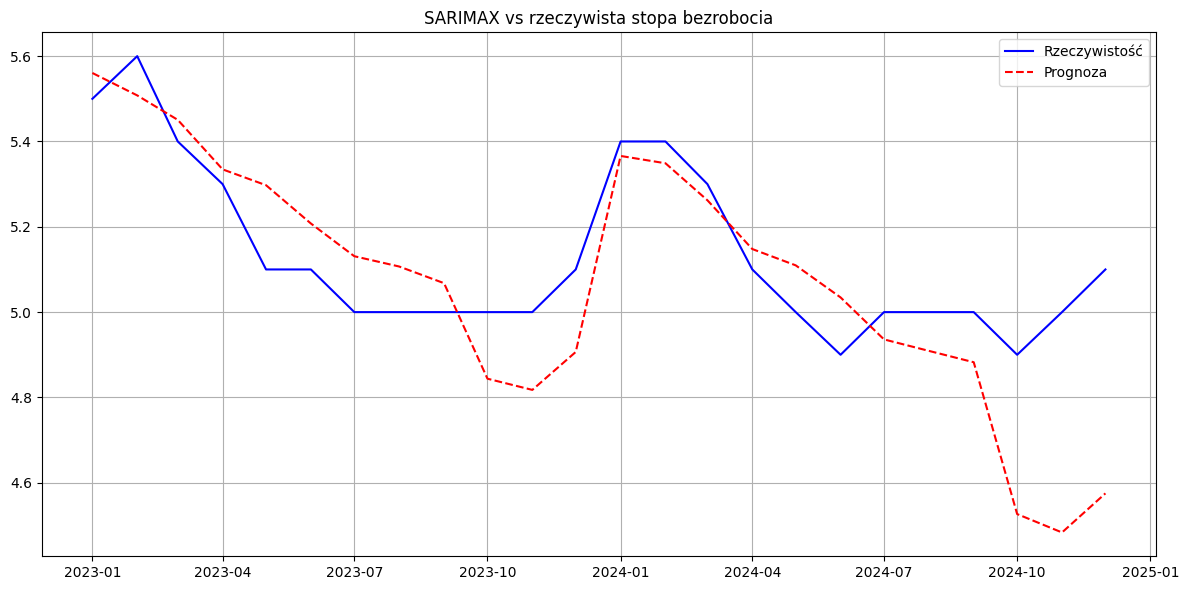

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                   stopa_bezrobocia   No. Observations:                  156
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                  57.766
Date:                            Tue, 29 Jul 2025   AIC                           -101.531
Time:                                    19:32:03   BIC                            -80.890
Sample:                                01-01-2010   HQIC                           -93.143
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Produkt krajowy brutto [GUS] -4.565e-06    1.2e-06     -3.814      0.000   -6.91e-06   -2.22e-06
przyrost naturalny           -1.283e-05   3.53e-06     -3.631      0.000   -1.97e-05    -5.9e-06
ar.L1                            0.6557      0.334      1.962      0.050       0.001       1.311
ma.L1                           -0.2128      0.337     -0.632      0.527      -0.872       0.447
ar.S.L12                         0.7450      0.146      5.094      0.000       0.458       1.032
ma.S.L12                        -0.5083      0.239     -2.129      0.033      -0.976      -0.040
sigma2                           0.0404      0.007      5.687      0.000       0.027       0.054
===================================================================================
Ljung-Box (L1) (Q):                  10.87   Jarque-Bera (JB):               995.33
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               3.89   Skew:                             2.08
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [25]:
result_sarimax_sarima_params = grid_search_sarimax(
    series=series_train,
    exog=exog_train_sig_2,
    p_range=[1],
    d_range=[1],
    q_range=[1],
    P_range=[1],
    D_range=[0],
    Q_range=[1],
    seasonal_period=12,
    verbose=False
)

best_sarimax_sarima_params = result_sarimax_sarima_params['best_model']
print("Optymalne parametry (z istotnymi exog):", result_sarimax_sarima_params['order'], result_sarimax_sarima_params['seasonal_order'])

# 4. Prognoza i ewaluacja
sarima_diff2_exog_forecast_sarima_params = best_sarimax_sarima_params.get_forecast(
    steps=len(series_test),
    exog=exog_test_sig_2
).predicted_mean
sarima_diff2_exog_forecast_sarima_params.index = series_test.index

metrics_sarima_diff2_exog_sarima_params = calculate_metrics(series_test, sarima_diff2_exog_forecast_sarima_params)
print("SARIMAX (tylko istotne exog) na testowym:")
print(metrics_sarima_diff2_exog_sarima_params)

plot_predictions(
    series_test,
    sarima_diff2_exog_forecast_sarima_params,
    title="SARIMAX vs rzeczywista stopa bezrobocia"
)

best_sarimax_sarima_params.summary()

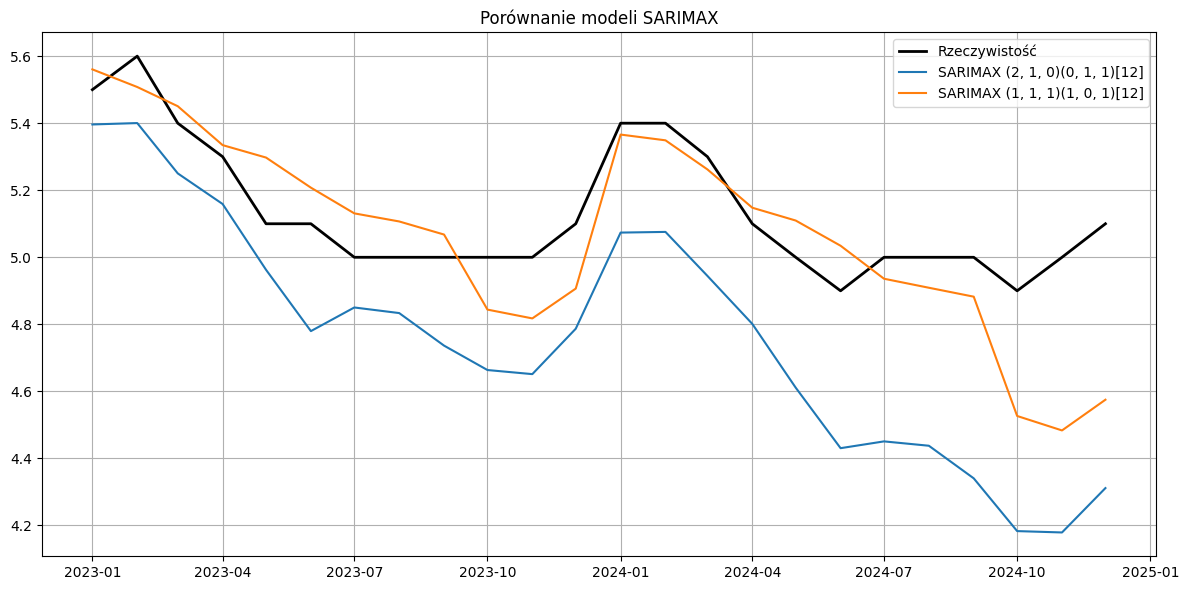

In [26]:
plot_multiple_preds(
    y_true=df['stopa_bezrobocia'].iloc[-24:],
    predictions={
        'SARIMAX (2, 1, 0)(0, 1, 1)[12]': sarima_diff2_exog_forecast,
        'SARIMAX (1, 1, 1)(1, 0, 1)[12]': sarima_diff2_exog_forecast_sarima_params
    },
    title='Porównanie modeli SARIMAX'
)

XGBoost

In [38]:
df = load_data('data/dane_2010plus.xlsx')

# Przygotowanie danych (target to diff2)
X_ml, y_ml = prepare_ml_data(df, target_col='stopa_bezrobocia')

# Podział na zbiór treningowy i testowy
X_train, X_test = X_ml.iloc[:-24], X_ml.iloc[-24:]
y_train, y_test = y_ml.iloc[:-24], y_ml.iloc[-24:]

# Czyszczenie nazw kolumn z niedozwolonych znaków
X_train.columns = X_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<>]', '', regex=True)

In [39]:
# scaler = StandardScaler()
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), 
                              index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), 
                             index=X_test.index, columns=X_test.columns)

<Axes: xlabel='rok_miesiac'>

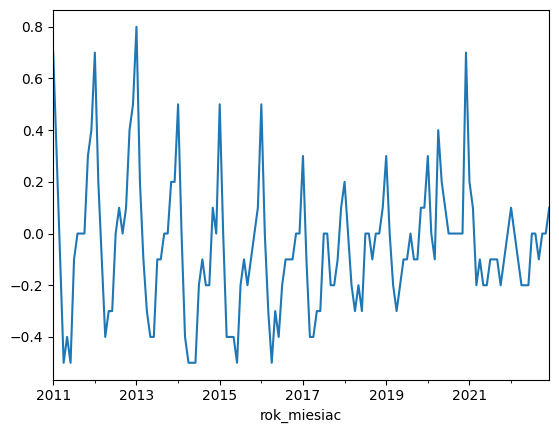

In [40]:
y_train.plot()

In [50]:
xgb_model = train_xgb_model(X_train_scaled.values, y_train, use_optuna=True, n_trials=1000)
xgb_predictions = xgb_model.predict(X_test_scaled.values)

[I 2025-07-29 19:42:59,190] A new study created in memory with name: no-name-c02b2138-c3b0-4d70-8323-39d9b3dbe755
[I 2025-07-29 19:42:59,423] Trial 0 finished with value: 0.1866571885006606 and parameters: {'n_estimators': 182, 'learning_rate': 0.1710371054122832, 'max_depth': 5, 'subsample': 0.8862273174495994, 'colsample_bytree': 0.9343170091686333, 'gamma': 0.5795819336676555, 'min_child_weight': 7, 'reg_alpha': 0.3969241115300992, 'reg_lambda': 0.25791679092206965}. Best is trial 0 with value: 0.1866571885006606.
[I 2025-07-29 19:42:59,532] Trial 1 finished with value: 0.21627784717070586 and parameters: {'n_estimators': 124, 'learning_rate': 0.2128057497019826, 'max_depth': 8, 'subsample': 0.8278835263247379, 'colsample_bytree': 0.8203618433676152, 'gamma': 3.254614685588834, 'min_child_weight': 5, 'reg_alpha': 0.3936472054748319, 'reg_lambda': 0.46818788862866534}. Best is trial 0 with value: 0.1866571885006606.
[I 2025-07-29 19:42:59,657] Trial 2 finished with value: 0.233104109

In [59]:
last_known_diff = df['stopa_bezrobocia'].iloc[-25]
y_pred = np.cumsum(xgb_model.predict(X_test_scaled.values)) + last_known_diff

{'MSE': 0.5034944151442139, 'RMSE': np.float64(0.7095734036336296), 'MAE': 0.5490293026280901}


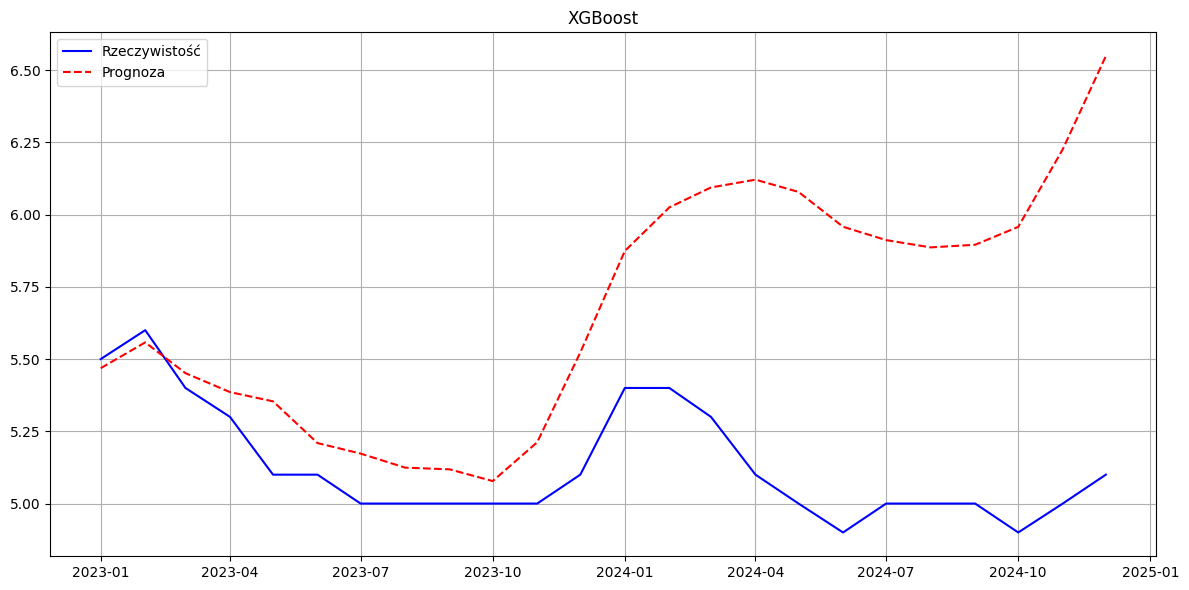

In [ ]:
xgb_level_forecast = pd.Series(y_pred, index=df.index[-24:])

# ewaluacja
metrics_xgb = calculate_metrics(df['stopa_bezrobocia'].iloc[-24:], xgb_level_forecast)
print(metrics_xgb)
plot_predictions(df['stopa_bezrobocia'].iloc[-24:], xgb_level_forecast,
                 title="XGBoost")

In [61]:
import pickle

with open('models/xgb_model_mse0326.pkl', 'rb') as f:
    xgb_model_best = pickle.load(f)

In [62]:
last_known_diff = df['stopa_bezrobocia'].iloc[-25]
y_pred = np.cumsum(xgb_model_best.predict(X_test_scaled.values)) + last_known_diff

{'MSE': 0.032633980717726184, 'RMSE': np.float64(0.180648777238392), 'MAE': 0.14034165575479474}


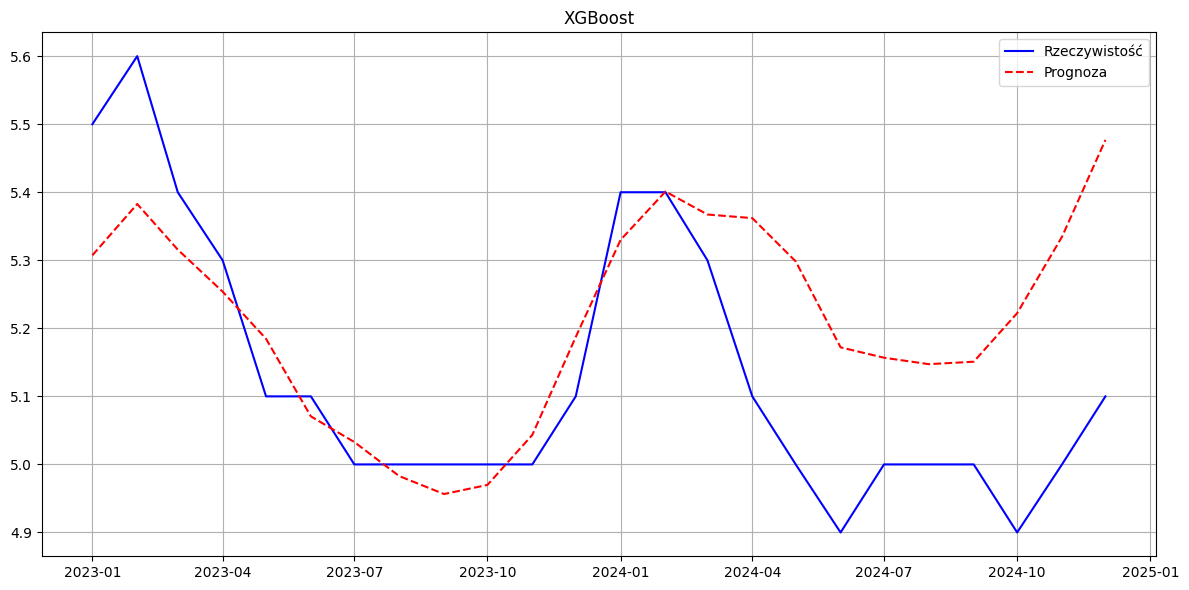

In [63]:
xgb_level_forecast = pd.Series(y_pred, index=df.index[-24:])

# ewaluacja
metrics_xgb = calculate_metrics(df['stopa_bezrobocia'].iloc[-24:], xgb_level_forecast)
print(metrics_xgb)
plot_predictions(df['stopa_bezrobocia'].iloc[-24:], xgb_level_forecast,
                 title="XGBoost")

In [64]:
xgb_model_optuna = xgb_model
xgb_model = xgb_model_best

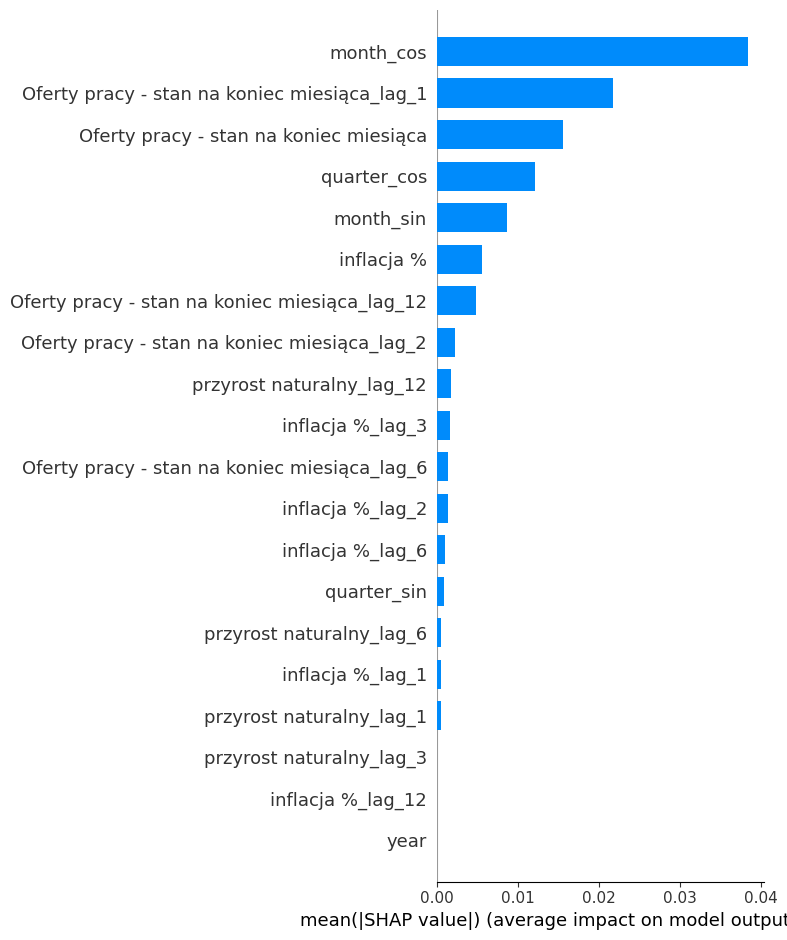

In [65]:
# 1. Stwórz Explainer i oblicz wartości SHAP
explainer = shap.Explainer(xgb_model, X_test_scaled.values, feature_names=X_test_scaled.columns)
shap_values = explainer(X_test_scaled.values)

# 2. Podsumowanie – wykres wartości średnich SHAP
shap.summary_plot(
    shap_values, 
    X_test_scaled.values, 
    feature_names=X_test_scaled.columns, 
    plot_type="bar"
)

In [70]:
params = xgb_model.get_params()
for key, value in params.items():
    print(f"{key}: {value}")

objective: reg:squarederror
base_score: None
booster: None
callbacks: None
colsample_bylevel: None
colsample_bynode: None
colsample_bytree: 0.913199021141491
device: None
early_stopping_rounds: None
enable_categorical: False
eval_metric: None
feature_types: None
feature_weights: None
gamma: 0.0041312983864412196
grow_policy: None
importance_type: None
interaction_constraints: None
learning_rate: 0.09500749086279095
max_bin: None
max_cat_threshold: None
max_cat_to_onehot: None
max_delta_step: None
max_depth: 4
max_leaves: None
min_child_weight: 1
missing: nan
monotone_constraints: None
multi_strategy: None
n_estimators: 239
n_jobs: None
num_parallel_tree: None
random_state: 42
reg_alpha: 0.17647096196999135
reg_lambda: 0.32502797670871086
sampling_method: None
scale_pos_weight: None
subsample: 0.7341980171044388
tree_method: None
validate_parameters: None
verbosity: None


Połączenie wielu modeli

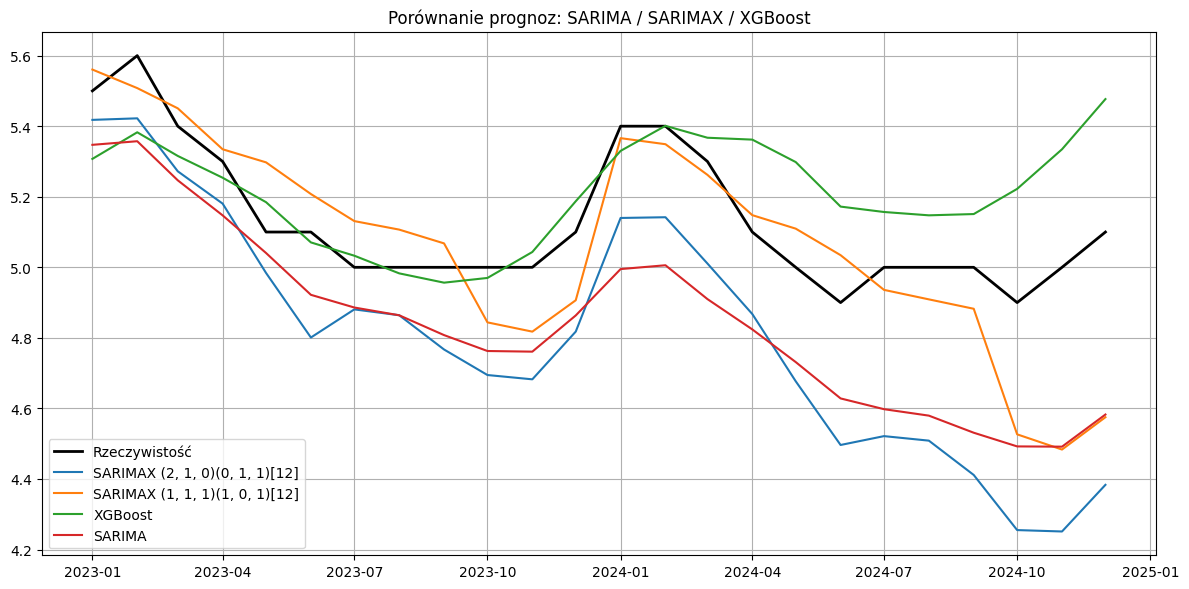

In [67]:
plot_multiple_preds(
    y_true=df['stopa_bezrobocia'].iloc[-24:],
    predictions={
        'SARIMAX (2, 1, 0)(0, 1, 1)[12]': sarima_diff2_exog_forecast_2,
        'SARIMAX (1, 1, 1)(1, 0, 1)[12]': sarima_diff2_exog_forecast_sarima_params,
        'XGBoost': xgb_level_forecast, 
        'SARIMA': forecast_diff2
    },
    title='Porównanie prognoz: SARIMA / SARIMAX / XGBoost'
)

In [71]:
# Tworzymy ramkę z wynikami
results_summary = pd.DataFrame([
    {'Model': 'SARIMA', **metrics_sarima_diff2},
    {'Model': 'SARIMAX (2, 1, 0)(0, 1, 1)[12]', **metrics_sarima_diff2_exog_2},
    {'Model': 'SARIMAX (1, 1, 1)(1, 0, 1)[12]', **metrics_sarima_diff2_exog_sarima_params},
    {'Model': 'XGBoost', **metrics_xgb} 
])

# Zaokrąglenie do 4 miejsc
results_summary = results_summary.round(4)
results_summary.set_index('Model', inplace=True)

print(results_summary)

                                   MSE    RMSE     MAE
Model                                                 
SARIMA                          0.0978  0.3127  0.2843
SARIMAX (2, 1, 0)(0, 1, 1)[12]  0.1408  0.3752  0.3229
SARIMAX (1, 1, 1)(1, 0, 1)[12]  0.0392  0.1979  0.1451
XGBoost                         0.0326  0.1806  0.1403
